# Aprendizado Supervisionado

Neste notebook vamos ver o **basico** de aprendizado supervisionado, usando as noticias que ja foram transformadas em vetores (TF-IDF) no notebook de PLN.

A ideia geral do supervisionado e:

1. Temos um conjunto de exemplos `(X, y)`, onde `X` sao as variaveis de entrada (*features*) e `y` e o que queremos prever (*alvo*).
2. Separamos os dados em **treino**, **calibracao** (tambem chamado de *validacao*) e **teste**.
3. Treinamos o modelo no **treino**.
4. Usamos a **calibracao** para escolher hiperparametros / ajustar o modelo sem espiar o teste.
5. Avaliamos o desempenho final no **teste**, que o modelo nunca viu.

Vamos fazer dois exemplos:

- **Classificacao**: prever se uma noticia tem a tag `INSS` (sim / nao).
- **Regressao**: prever o numero de palavras unicas da noticia.

Em ambos os casos, as *features* serao as colunas do TF-IDF.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    r2_score,
)

## Carregando os dados

Usamos o `tfidf.csv` (matriz TF-IDF + metadados) e o `noticias.csv` (texto original e tags).

In [2]:
df_tfidf = pd.read_csv("../dados/tfidf.csv")
df_bow = pd.read_csv("../dados/bow.csv")

print("TF-IDF:", df_tfidf.shape)
print("BoW:   ", df_bow.shape)
df_tfidf.head(2)

TF-IDF: (271, 10903)
BoW:    (271, 10904)


,data,tags,titulo,url,tfidf_aab,tfidf_aapen,tfidf_aasap,tfidf_abaixo,tfidf_abalos,tfidf_abandona,...,tfidf_zema,tfidf_zenaide,tfidf_zendron,tfidf_zequinha,tfidf_zerbone,tfidf_zero,tfidf_zettel,tfidf_zimbardo,tfidf_zona,tfidf_zumbi
0,2026-03-30T17:31:28-03:00,"['Agricultura familiar ', 'Emendas parlamentar...",Chico Rodrigues destaca ações em Roraima e cri...,https://www12.senado.leg.br/noticias/materias/...,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,2026-03-27T19:39:12-03:00,"['Aposentados', 'INSS', 'Pensionistas']","Com mais de 4 mil páginas, relatório da CPMI p...",https://www12.senado.leg.br/noticias/materias/...,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.003677,0.0,0.0,0.0,0.0,0.0,0.0


## Montando X (features)

Pegamos so as colunas que comecam com `tfidf_` para formar a matriz `X`.

In [3]:
colunas_tfidf = [c for c in df_tfidf.columns if c.startswith("tfidf_")]
X = df_tfidf[colunas_tfidf].values
print("X:", X.shape)

X: (271, 10899)


## 1) Classificacao - a noticia fala de INSS?

A coluna `tags` e uma lista de tags como uma string. Vamos criar um alvo binario `y_clf` que vale `1` quando a tag `INSS` aparece e `0` caso contrario.

In [4]:
y_clf = df_tfidf["tags"].fillna("").str.contains("INSS").astype(int).values

print("Distribuicao das classes:")
print(pd.Series(y_clf).value_counts())

Distribuicao das classes:
0    203
1     68
Name: count, dtype: int64


### Separando treino / calibracao / teste

Vamos usar aproximadamente **60% treino, 20% calibracao, 20% teste**. Fazemos isso em duas etapas com `train_test_split`:

1. Separamos 20% para teste.
2. Dos 80% restantes, separamos 25% para calibracao (que corresponde a 20% do total).

Usamos `stratify=y_clf` para manter a proporcao das classes em cada subconjunto.

In [5]:
X_tmp, X_teste, y_tmp, y_teste = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
X_treino, X_calib, y_treino, y_calib = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"treino:    {X_treino.shape}")
print(f"calibracao:{X_calib.shape}")
print(f"teste:     {X_teste.shape}")

treino:    (162, 10899)
calibracao:(54, 10899)
teste:     (55, 10899)


### Treinando o modelo

Vamos usar uma **Random Forest** (floresta aleatoria), que e um conjunto de varias arvores de decisao. E um modelo bem versatil e costuma ser uma boa primeira escolha.

In [6]:
modelo_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
modelo_clf.fit(X_treino, y_treino)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Usando a calibracao para escolher um limiar

A Random Forest tambem devolve uma **probabilidade** (proporcao de arvores que votaram naquela classe). Por padrao classificamos como `1` se essa probabilidade for `> 0.5`, mas esse limiar pode nao ser o melhor.

Vamos usar o conjunto de **calibracao** para testar varios limiares e escolher o que da maior acuracia. Importante: o teste nao e usado aqui.

In [7]:
probs_calib = modelo_clf.predict_proba(X_calib)[:, 1]

limiares = np.linspace(0.1, 0.9, 17)
resultados = []
for t in limiares:
    pred = (probs_calib > t).astype(int)
    acc = accuracy_score(y_calib, pred)
    resultados.append((t, acc))

df_lim = pd.DataFrame(resultados, columns=["limiar", "acuracia_calib"])
melhor_limiar = df_lim.loc[df_lim["acuracia_calib"].idxmax(), "limiar"]
print(f"Melhor limiar pela calibracao: {melhor_limiar:.2f}")
df_lim

Melhor limiar pela calibracao: 0.50


,limiar,acuracia_calib
0,0.10,0.759259
1,0.15,0.851852
2,0.20,0.888889
3,0.25,0.888889
4,0.30,0.870370
5,0.35,0.870370
6,0.40,0.870370
7,0.45,0.870370
8,0.50,0.907407
9,0.55,0.907407


### Avaliando no teste

Agora aplicamos o modelo (com o limiar escolhido na calibracao) no conjunto de **teste** - dados que ele nunca viu.

In [8]:
probs_teste = modelo_clf.predict_proba(X_teste)[:, 1]
pred_teste = (probs_teste > melhor_limiar).astype(int)

acc = accuracy_score(y_teste, pred_teste)
prec = precision_score(y_teste, pred_teste)
rec = recall_score(y_teste, pred_teste)
f1 = f1_score(y_teste, pred_teste)

print(f"Acuracia: {acc:.3f}")
print(f"Precisao: {prec:.3f}")
print(f"Recall:   {rec:.3f}")
print(f"F1:       {f1:.3f}\n")

print("Relatorio completo:")
print(classification_report(y_teste, pred_teste, target_names=["nao-INSS", "INSS"]))

Acuracia: 0.909
Precisao: 0.846
Recall:   0.786
F1:       0.815

Relatorio completo:
              precision    recall  f1-score   support

    nao-INSS       0.93      0.95      0.94        41
        INSS       0.85      0.79      0.81        14

    accuracy                           0.91        55
   macro avg       0.89      0.87      0.88        55
weighted avg       0.91      0.91      0.91        55



### Matriz de confusao

A matriz de confusao mostra quantos exemplos de cada classe foram preditos como cada classe. As linhas sao o real e as colunas o previsto.

- Diagonal = acertos (verdadeiros negativos e verdadeiros positivos).
- Fora da diagonal = erros (falsos negativos e falsos positivos).

Matriz de confusao (linhas=real, colunas=previsto):
          nao-INSS  INSS
nao-INSS        39     2
INSS             3    11


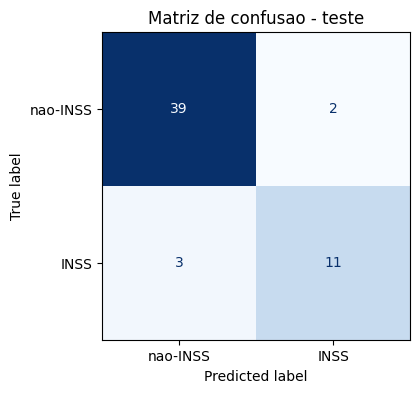

In [9]:
cm = confusion_matrix(y_teste, pred_teste)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm, index=["nao-INSS", "INSS"], columns=["nao-INSS", "INSS"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["nao-INSS", "INSS"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusao - teste")
plt.show()

## 2) Regressao - prever o numero de palavras unicas

Agora vamos fazer uma **regressao**: prever um valor numerico em vez de uma classe. O alvo sera `palavras_unicas` (numero de palavras diferentes em cada noticia), que esta no `bow.csv`.

As *features* continuam sendo o TF-IDF.

In [10]:
y_reg = df_bow["palavras_unicas"].values

print("Estatisticas do alvo:")
print(pd.Series(y_reg).describe())

Estatisticas do alvo:
count    271.000000
mean     203.944649
std      110.662586
min       32.000000
25%      130.000000
50%      169.000000
75%      243.000000
max      763.000000
dtype: float64


### Separando treino / calibracao / teste

Mesma ideia da classificacao, mas agora **sem** `stratify` (alvo continuo).

In [11]:
X_tmp, X_teste_r, y_tmp, y_teste_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
X_treino_r, X_calib_r, y_treino_r, y_calib_r = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42
)

print(f"treino:    {X_treino_r.shape}")
print(f"calibracao:{X_calib_r.shape}")
print(f"teste:     {X_teste_r.shape}")

treino:    (162, 10899)
calibracao:(54, 10899)
teste:     (55, 10899)


### Treinando e usando a calibracao para escolher o numero de arvores

Vamos usar uma **Random Forest Regressor**. Um hiperparametro importante e `n_estimators` (quantas arvores). Treinamos varios modelos no treino, escolhemos o `n_estimators` que tem menor erro na **calibracao**, e so depois avaliamos no teste.

In [12]:
n_estimators_list = [10, 50, 100, 200, 400]
resultados_reg = []
modelos = {}

for n in n_estimators_list:
    modelo = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    modelo.fit(X_treino_r, y_treino_r)
    pred_calib = modelo.predict(X_calib_r)
    mae = mean_absolute_error(y_calib_r, pred_calib)
    resultados_reg.append((n, mae))
    modelos[n] = modelo

df_reg = pd.DataFrame(resultados_reg, columns=["n_estimators", "MAE_calib"])
melhor_n = int(df_reg.loc[df_reg["MAE_calib"].idxmin(), "n_estimators"])
print(f"Melhor n_estimators pela calibracao: {melhor_n}")
df_reg

Melhor n_estimators pela calibracao: 10


,n_estimators,MAE_calib
0,10,38.407407
1,50,41.058889
2,100,42.398333
3,200,41.404537
4,400,40.473981


### Avaliando no teste

Usamos o modelo treinado com o melhor `alpha` e olhamos duas metricas:

- **MAE** (erro absoluto medio): em media, quantas palavras unicas o modelo erra.
- **R²**: o quanto da variancia do alvo o modelo explica (1.0 = perfeito, 0.0 = igual a prever a media).

In [13]:
modelo_final = modelos[melhor_n]
pred_teste_r = modelo_final.predict(X_teste_r)

print(f"MAE no teste: {mean_absolute_error(y_teste_r, pred_teste_r):.2f}")
print(f"R²  no teste: {r2_score(y_teste_r, pred_teste_r):.3f}")

df_comp = pd.DataFrame({
    "real": y_teste_r,
    "previsto": pred_teste_r.round(1),
}).head(10)
df_comp

MAE no teste: 35.19
R²  no teste: 0.725


,real,previsto
0,155,174.4
1,432,312.8
2,118,134.2
3,119,124.0
4,614,425.2
5,179,215.3
6,83,102.9
7,127,143.5
8,189,179.8
9,217,172.6


## Resumindo

- Em **supervisionado**, precisamos de `(X, y)` e de uma separacao honesta entre treino, calibracao e teste.
- O **treino** ajusta o modelo.
- A **calibracao** serve para escolher hiperparametros (limiar, `alpha`, etc.) sem usar o teste.
- O **teste** so e usado no final para estimar como o modelo se sai em dados novos.
- Para classificacao usamos metricas como **acuracia**, **precisao**, **recall**.
- Para regressao usamos metricas como **MAE** e **R²**.

A partir daqui da pra trocar o modelo (arvore, random forest, knn, ...), trocar as features (BoW em vez de TF-IDF) ou trocar o alvo (outra tag, tamanho do texto, etc.) e ver como o resultado muda.